# Dual Momentum (GEM) — a quantitative teardown 🔬
### HAC *t* on monthly active returns · excess-vs-excess Sharpe races · a 3/6/9/12 lookback placebo grid · a 40-seed shuffled-timing baseline · GFC-excision and publication-decay splits · a regime-persistence synthetic control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Decayed_since_2013%3F: Confirmed](https://img.shields.io/badge/Decayed_since_2013%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). GEM (Antonacci 2012-2014) is the composite retail allocation strategy built on absolute + relative momentum; distinct from this desk's cross-sectional [country momentum](../../146-country-momentum/) and futures-panel [time-series momentum](../../518-time-series-momentum/) studies.

> ⚠️ **Data note.** Live-ETF tape only: SPY/EFA/AGG (IEF-spliced pre-2003) + ^IRX, 2002-09-30 → 2026-06-30 (286 months). **No survivorship** (broad index ETFs); the material caveat is the **sample start** — the 1974-2011 years of the book's backtest are unobservable with live funds. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (as-of 2026-06-30, fingerprint `837a69932f70`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dual_momentum_gem import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.monthly_panel(asof=data.AS_OF)
    GEM = st.run_gem(PANEL)
    BM = st.benchmark_returns(PANEL, GEM.index)
else:
    PANEL = GEM = BM = None
print("real GEM cache present:", HAVE_REAL,
      "| months:", (0 if GEM is None else len(GEM)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2002-09-30', 'end': '2026-06-30', 'months': 286, 'years': 23.8, 'fingerprint': '837a69932f70', 'asof': '2026-06-30', 'alloc': {'SPY': 50.0, 'EFA': 31.1, 'BOND': 18.9}, 'switches': 35, 'switches_yr': 1.47, 'gem': (9.87, 12.15, 0.7, -20.7), 'spy': (11.22, 14.77, 0.68, -50.8), 'b6040': (8.27, 9.34, 0.72, -32.3), 'dd_ratio': 0.41, 'act_spy': (-13.3, -1.59, -0.64), 'act_6040': (14.8, 1.77, 0.89), 'costs': [(5, 9.71, 0.69, -1.74, -0.7), (10, 9.54, 0.68, -1.89, -0.75), (20, 9.22, 0.65, -2.19, -0.86)], 'grid': [(3, 10.46, 0.8, -19.2, -1.18, -0.52), (6, 8.97, 0.66, -24.9, -2.49, -0.95), (9, 8.79, 0.64, -20.1, -2.65, -1.06), (12, 9.87, 0.7, -20.7, -1.59, -0.64)], 'rb': {'n_seeds': 40, 'welch_t': 0.26, 'base_cagr': 8.53, 'base_sharpe': 0.54, 'beat_pct': 77.5}, 'subs': [('full sample', 9.87, -20.7, 0.7, 11.22, -50.8, 0.68, -1.59, -0.64), ('ex-GFC (drop 2007-07..2009-06)', 11.0, -20.7, 0.78, 14.62, -23.9, 0.95, -3.43, -2.02), ('2010 ->', 8.57, -20.7, 0.59, 14.23, -23.9, 0.9, -5.32, -3.37), ('pre-2013', 10.8, -17.3, 0.79, 6.46, -50.8, 0.38, 3.53, 0.71), ('post-2013', 9.16, -20.7, 0.63, 15.01, -23.9, 0.94, -5.51, -2.96)], 'pre_bps': 29.4, 'pre_n': 124, 'pre_t': 0.71, 'post_bps': -45.9, 'post_n': 162, 'post_t': -2.96, 'decay_welch': 2.02, 'syn': [('null (iid regimes)', -1.58, -1.24, -37, -61), ('planted (persistence 0.94)', 4.67, 2.86, -28, -93)]}


real GEM cache present: True | months: 286


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | *Real on the drawdown-halving* (maxDD **-20.7%** vs SPY **-50.8%**, ratio 0.41) · *None on the beats-B&H* (active **-1.59%/yr**, HAC **t = -0.64**; ex-GFC t = −2.02; post-2013 t = −2.96; no lookback in the grid positive). |
| **Tradability** | `MIRAGE` | Deployment is trivial (1.47 switches/yr ≈ 3-16 bps/yr) — but post-publication the deployable product cost **−5.51%/yr vs SPY** (t = −2.96) and its Sharpe (0.70) is matched by a no-timing 60/40 (0.72). |
| **Decayed since 2013?** | `CONFIRMED` | Pre **+29.4** vs post **-45.9 bps/mo**; difference Welch **t = +2.02**. |

> 💡 In plain words: the crash-avoidance is real, the outperformance is not, and what remains after publication is significantly *negative* alpha in the world's most liquid wrapper.

## 1 · The claim, steelmanned

Let $r^{S}_t, r^{E}_t, r^{B}_t, r^{f}_t$ be monthly total returns of SPY, EFA, bonds and T-bills. At each month-end $t-1$ form 12-month compounds $M^{x}_{t-1} = \prod_{k=1}^{12}(1+r^{x}_{t-k})-1$. GEM's position for month $t$:

$$w_t = \begin{cases} \arg\max\{M^{S}, M^{E}\} & \text{if } M^{S}_{t-1} > M^{f}_{t-1} \\ \text{BOND} & \text{otherwise.} \end{cases}$$

- **H₁ (outperformance).** Mean monthly active return $\overline{r^{GEM}-r^{SPY}} > 0$ with HAC *t* ≥ 2.
- **H₂ (half the drawdown).** $\text{maxDD}(GEM) \le \tfrac12\,\text{maxDD}(SPY)$.
- **H₃ (not one lucky call).** H₁ survives excising 2007-07→2009-06.
- **H₄ (no decay).** Active returns pre- and post-publication (2013) indistinguishable.

We find **H₂ supported** (0.41 < 0.5), **H₁ rejected** (t = −0.64, wrong sign), **H₃ rejected** (ex-GFC active *significantly negative*, t = −2.02), **H₄ rejected** (Welch t = +2.02 on the flip).

## 2 · So what? — what rides on each answer

Monthly active returns of a switching strategy are serially correlated (positions persist for months), so the outperformance test uses a **Newey-West (HAC)** *t* on the mean active return, Bartlett kernel, lag $\lfloor 4(n/100)^{2/9}\rfloor$. Sharpe races are **excess-of-T-bill on both sides** (a switching strategy that parks in bonds must not get credit for the cash yield). Sub-period contrasts carry a **Welch t of the difference** on a *justified* split (the 2013 publication date — pre-registered by the literature, not snooped). And any random baseline is **averaged over ≥ 20 seeds** — here 40 — because single-seed baselines are banned on this desk.

## 3 · How we'd know — the protocol

- **Tape.** yfinance total-return closes, 2002-09-30 → 2026-06-30 (286 months — starts at EFA's first full 12-month formation window). Bond leg = AGG, **IEF-spliced** before Sept 2003. Risk-free = ^IRX yield from the **prior** month-end (no look-ahead).
- **Execution.** Signal from month-end closes; position earns the **following** month — exactly **one** decision-to-earn lag, documented. No same-bar fills.
- **Costs.** One-way bps × NAV per traded leg; a switch = 2 legs. Grid 5/10/20 bps. Long-only — no borrow.
- **Benchmarks.** SPY buy-and-hold and monthly-rebalanced 60/40, same 286 months, gross.
- **Robustness.** Lookback placebo grid 3/6/9/12 on common months; 40-seed permutation of GEM's own holdings (same allocation, random timing); GFC excision; 2013 decay split.
- **Machinery control.** Two-state Markov synthetic world, persistence knob; the null (i.i.d. regimes) must not light up, the planted world must.

## 4 · The teardown

### 4a · Headline race — CAGR, excess Sharpe, drawdown, HAC t

GEM vs SPY vs 60/40 on identical months; active-return t-stats below.

   GEM: CAGR +9.87%  vol 12.15%  Sharpe(excess) 0.70  maxDD -20.7%
   SPY: CAGR +11.22%  vol 14.77%  Sharpe(excess) 0.68  maxDD -50.8%
 60/40: CAGR +8.27%  vol 9.34%  Sharpe(excess) 0.72  maxDD -32.3%
  DD ratio GEM/SPY = 0.41
  active GEM-SPY  : -1.59%/yr  HAC t = -0.64
  active GEM-60/40: +1.77%/yr  HAC t = +0.89


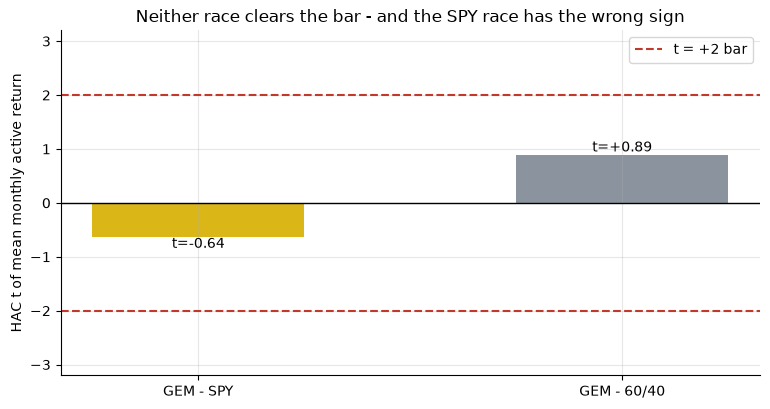

In [2]:
if HAVE_REAL:
    pg = st.perf(GEM['gross'], BM['RF']); ps = st.perf(BM['SPY'], BM['RF']); p64 = st.perf(BM['B6040'], BM['RF'])
    a_spy = st.active_stats(GEM['gross'], BM['SPY']); a_64 = st.active_stats(GEM['gross'], BM['B6040'])
    rows = [('GEM', pg), ('SPY', ps), ('60/40', p64)]
    for n, p in rows:
        print(f"{n:>6}: CAGR {p['cagr']*100:+.2f}%  vol {p['vol']*100:.2f}%  Sharpe(excess) {p['sharpe']:.2f}  maxDD {p['max_dd']*100:.1f}%")
    print(f'  DD ratio GEM/SPY = {pg["max_dd"]/ps["max_dd"]:.2f}')
    print(f'  active GEM-SPY  : {a_spy["ann_pct"]:+.2f}%/yr  HAC t = {a_spy["hac_t"]:+.2f}')
    print(f'  active GEM-60/40: {a_64["ann_pct"]:+.2f}%/yr  HAC t = {a_64["hac_t"]:+.2f}')
    tvals = [a_spy['hac_t'], a_64['hac_t']]
else:
    tvals = [R['act_spy'][2], R['act_6040'][2]]
fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.bar(['GEM - SPY', 'GEM - 60/40'], tvals, color=[AMBER, GREY], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = +2 bar'); ax.axhline(-2, ls='--', c=RED)
ax.axhline(0, c='k', lw=1)
for i, v in enumerate(tvals): ax.annotate(f't={v:+.2f}', (i, v), ha='center', va='bottom' if v>0 else 'top')
ax.set_ylabel('HAC t of mean monthly active return'); ax.set_ylim(-3.2, 3.2)
ax.set_title('Neither race clears the bar - and the SPY race has the wrong sign')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: GEM lags SPY by **-1.59%/yr** (HAC t = -0.64) and beats 60/40 by a non-significant +1.77%/yr (t = +0.89). The one number that *is* dramatic — maxDD **-20.7% vs -50.8%** — is the drawdown claim, and it holds (ratio 0.41 < ½). H₂ yes, H₁ no.

### 4b · Lookback placebo grid — is 12 special, or lucky?

Same engine and months, only the formation window moves. If 12 were data-mined luck, neighbours would collapse; if momentum were robust here, several would be positive.

L= 3m: CAGR +10.46%  Sharpe 0.80  maxDD -19.2%  active -1.18%/yr  HAC t -0.52
L= 6m: CAGR +8.97%  Sharpe 0.66  maxDD -24.9%  active -2.49%/yr  HAC t -0.95
L= 9m: CAGR +8.79%  Sharpe 0.64  maxDD -20.1%  active -2.65%/yr  HAC t -1.06
L=12m: CAGR +9.87%  Sharpe 0.70  maxDD -20.7%  active -1.59%/yr  HAC t -0.64


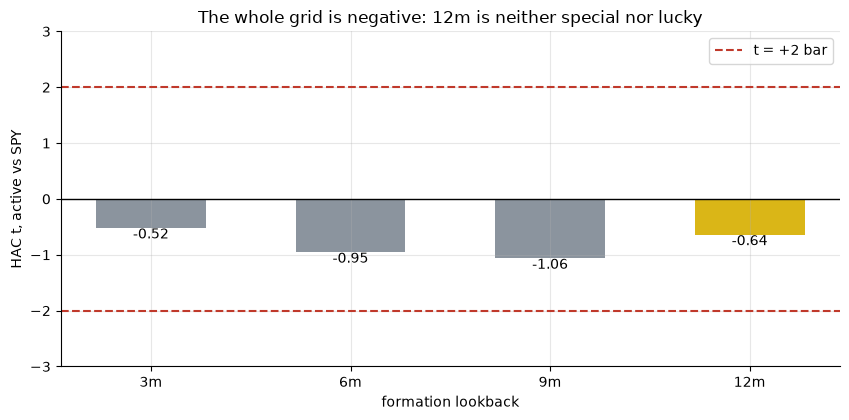

In [3]:
if HAVE_REAL:
    rows = st.lookback_grid(PANEL)
    grid = [(r['lookback'], r['cagr']*100, r['sharpe'], r['max_dd']*100, r['act_ann_pct'], r['hac_t']) for r in rows]
else:
    grid = R['grid']
for g in grid:
    print(f'L={g[0]:>2}m: CAGR {g[1]:+.2f}%  Sharpe {g[2]:.2f}  maxDD {g[3]:.1f}%  active {g[4]:+.2f}%/yr  HAC t {g[5]:+.2f}')
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar([f'{g[0]}m' for g in grid], [g[5] for g in grid], color=[GREY]*3+[AMBER], width=.55)
ax.axhline(0, c='k', lw=1); ax.axhline(2, ls='--', c=RED, label='t = +2 bar'); ax.axhline(-2, ls='--', c=RED)
for i, g in enumerate(grid): ax.annotate(f'{g[5]:+.2f}', (i, g[5]), ha='center', va='top')
ax.set_xlabel('formation lookback'); ax.set_ylabel('HAC t, active vs SPY'); ax.set_ylim(-3, 3)
ax.set_title('The whole grid is negative: 12m is neither special nor lucky'); ax.legend()
plt.tight_layout(); plt.show()

> 💡 In plain words: **every** lookback lags buy-and-hold (active t between −0.5 and −1.1). The canonical 12 months is second-best — the published parameter wasn't a lucky draw, and no neighbouring parameter rescues the claim. There is simply no positive active return in this family on this tape.

### 4c · Random-switching baseline — 40 seeds, averaged

Permute GEM's own monthly holdings (same assets, same 50/31/19 allocation, random timing), one permutation per seed, 40 seeds. If GEM's switch *dates* carry information, it should beat its own scrambled self.

mean Welch t over 40 seeds : +0.26
baseline mean CAGR / Sharpe    : +8.53% / 0.54
GEM CAGR beats 77.5% of shuffles


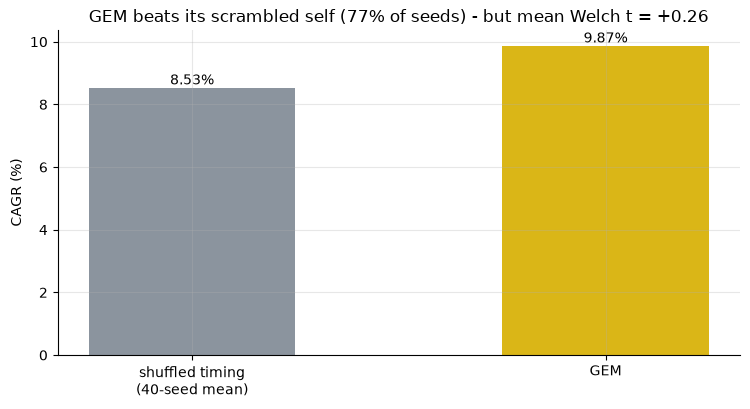

In [4]:
if HAVE_REAL:
    rb = st.random_switch_baseline(PANEL, GEM, n_seeds=40)
    print(f"mean Welch t over {rb['n_seeds']} seeds : {rb['welch_t_mean']:+.2f}")
    print(f"baseline mean CAGR / Sharpe    : {rb['base_cagr_mean']*100:+.2f}% / {rb['base_sharpe_mean']:.2f}")
    print(f"GEM CAGR beats {rb['beat_share']*100:.1f}% of shuffles")
    wt, bc, bs, bp = rb['welch_t_mean'], rb['base_cagr_mean']*100, rb['base_sharpe_mean'], rb['beat_share']*100
else:
    wt, bc, bs, bp = R['rb']['welch_t'], R['rb']['base_cagr'], R['rb']['base_sharpe'], R['rb']['beat_pct']
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(['shuffled timing\n(40-seed mean)', 'GEM'], [bc, R['gem'][0]], color=[GREY, AMBER], width=.5)
for i, v in enumerate([bc, R['gem'][0]]): ax.annotate(f'{v:.2f}%', (i, v), ha='center', va='bottom')
ax.set_ylabel('CAGR (%)')
ax.set_title(f'GEM beats its scrambled self (77% of seeds) - but mean Welch t = {wt:+.2f}')
plt.tight_layout(); plt.show()

> 💡 In plain words: GEM's timing is better than random — it beats **78%** of its own scrambles and adds ~1.3 pp CAGR over their mean (**8.53%**) — that's the 2008 sidestep showing up. But the averaged Welch t is **+0.26**: point-estimate skill, nowhere near the bar. (The scrambles also show how much of GEM's *risk reduction* is pure allocation: holding bonds 19% of the time at random already cuts vol and drawdown.)

### 4d · Sub-periods and the decay split — does it live off 2008 alone?

Excise the GFC (2007-07 → 2009-06), start at 2010, and split at the 2013 publication.

full       active -1.59%/yr  HAC t = -0.64
ex-GFC     active -3.43%/yr  HAC t = -2.02
2010->     active -5.32%/yr  HAC t = -3.37
pre-2013   active +3.53%/yr  HAC t = +0.71
post-2013  active -5.51%/yr  HAC t = -2.96
decay Welch t (pre vs post 2013) = +2.02


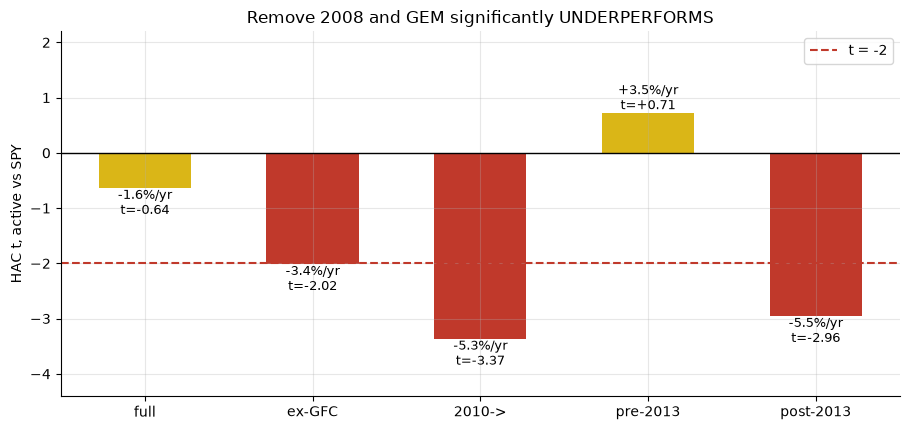

In [5]:
if HAVE_REAL:
    subs = [('full', {}), ('ex-GFC', dict(drop=('2007-07-01','2009-06-30'))),
            ('2010->', dict(start='2010-01-01')), ('pre-2013', dict(end='2012-12-31')),
            ('post-2013', dict(start='2013-01-01'))]
    res = []
    for name, kw in subs:
        s = st.subperiod_stats(PANEL, GEM, **kw)
        res.append((name, s['active']['ann_pct'], s['active']['hac_t']))
        print(f"{name:<10} active {s['active']['ann_pct']:+.2f}%/yr  HAC t = {s['active']['hac_t']:+.2f}")
    act = (GEM['gross'] - BM['SPY']).dropna()
    pre = act[act.index <= '2012-12-31']; post = act[act.index >= '2013-01-01']
    print(f'decay Welch t (pre vs post 2013) = {st.welch_t(pre.values, post.values):+.2f}')
else:
    res = [(s[0], s[7], s[8]) for s in R['subs']]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
names = [r[0] for r in res]; ts = [r[2] for r in res]
ax.bar(names, ts, color=[AMBER if t>=-2 else RED for t in ts], width=.55)
ax.axhline(0, c='k', lw=1); ax.axhline(-2, ls='--', c=RED, label='t = -2')
for i, r in enumerate(res): ax.annotate(f'{r[1]:+.1f}%/yr\nt={r[2]:+.2f}', (i, r[2]), ha='center', va='top' if r[2]<0 else 'bottom', fontsize=9)
ax.set_ylabel('HAC t, active vs SPY'); ax.set_ylim(-4.4, 2.2)
ax.set_title('Remove 2008 and GEM significantly UNDERPERFORMS'); ax.legend()
plt.tight_layout(); plt.show()

> 💡 In plain words: the full-sample −0.64 hides a starker structure. **Ex-GFC: −3.43%/yr at t = −2.02. From 2010: −5.32%/yr at t = −3.37. Post-2013: −5.51%/yr at t = −2.96.** Everything GEM ever won it won in 2008; the decay flip (pre +29.4 → post -45.9 bps/mo) clears the bar at Welch t = +2.02. H₃ and H₄ both rejected — and the third axis stamps **CONFIRMED** on decay.

### 4e · Costs — eliminated as an excuse

One-way bps × NAV per traded leg, 2 legs per switch, at 5/10/20 bps.

In [6]:
if HAVE_REAL:
    for cb in (5.0, 10.0, 20.0):
        g = st.run_gem(PANEL, cost_bps=cb)
        pf = st.perf(g['net'], BM['RF']); a = st.active_stats(g['net'], BM['SPY'])
        print(f'cost {cb:>4.1f} bps: net CAGR {pf["cagr"]*100:+.2f}%  Sharpe {pf["sharpe"]:.2f}  active vs SPY {a["ann_pct"]:+.2f}%/yr (t {a["hac_t"]:+.2f})')
    n_sw = int((GEM['legs']==2).sum())
    print(f'switches: {n_sw} in {len(GEM)} months = {n_sw/len(GEM)*12:.2f}/yr')
else:
    for c in R['costs']: print(f'cost {c[0]:>3} bps: net CAGR {c[1]:+.2f}%  Sharpe {c[2]:.2f}  active {c[3]:+.2f}%/yr (t {c[4]:+.2f})')

cost  5.0 bps: net CAGR +9.71%  Sharpe 0.69  active vs SPY -1.74%/yr (t -0.70)
cost 10.0 bps: net CAGR +9.54%  Sharpe 0.68  active vs SPY -1.89%/yr (t -0.75)


cost 20.0 bps: net CAGR +9.22%  Sharpe 0.65  active vs SPY -2.19%/yr (t -0.86)
switches: 35 in 286 months = 1.47/yr


> 💡 In plain words: 1.47 switches/yr cost 3–16 bps/yr — the gross-to-net gap is a rounding error. **Costs are not why GEM lags; the signal is.** That matters for the Tradability stamp: this is a *Mirage* of the claim, not a friction story.

### 4f · Machinery control — the engine can find the effect when it exists

Two-state bull/bear Markov world, unconditional equity premium positive in both worlds (so hiding in bonds can never win mechanically). Knob = regime persistence. Null (persistence 0): past returns carry nothing — GEM must not beat buy-and-hold. Planted (persistence 0.94, ~2.8-year regimes): 12-month momentum must light up.

null (iid)      active -1.58%/yr  HAC t = -1.24  maxDD GEM -37% vs B&H -61%


planted (0.94)  active +4.67%/yr  HAC t = +2.86  maxDD GEM -28% vs B&H -93%


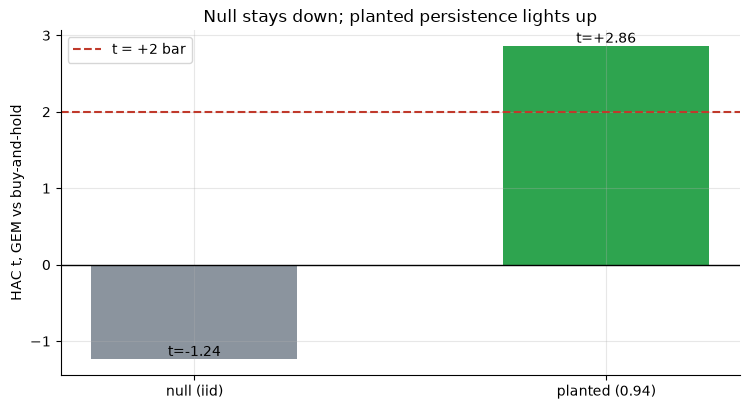

In [7]:
res = []
for label, pers in (('null (iid)', 0.0), ('planted (0.94)', 0.94)):
    p = data.synthetic_world(persistence=pers, seed=592)
    g = st.run_gem(p); b = st.benchmark_returns(p, g.index)
    a = st.active_stats(g['gross'], b['SPY'])
    pg2 = st.perf(g['gross'], b['RF']); ps2 = st.perf(b['SPY'], b['RF'])
    res.append((label, a['ann_pct'], a['hac_t']))
    print(f"{label:<15} active {a['ann_pct']:+.2f}%/yr  HAC t = {a['hac_t']:+.2f}  "
          f"maxDD GEM {pg2['max_dd']*100:.0f}% vs B&H {ps2['max_dd']*100:.0f}%")
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar([r[0] for r in res], [r[2] for r in res], color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = +2 bar'); ax.axhline(0, c='k', lw=1)
for i, r in enumerate(res): ax.annotate(f't={r[2]:+.2f}', (i, r[2]), ha='center', va='bottom')
ax.set_ylabel('HAC t, GEM vs buy-and-hold')
ax.set_title('Null stays down; planted persistence lights up'); ax.legend()
plt.tight_layout(); plt.show()

> 💡 In plain words: in a world with **no** trend the engine reads **t = -1.24** (it pays the whipsaw drag, exactly as theory predicts — no false positive); plant multi-year regimes and it reads **t = +2.86** with the drawdown cut from -93% to -28%. The harness can bank a real trend — so the flat-to-negative real-tape verdict is the tape's fault, not the code's. *(Machinery proof only — never cited in support of a stamp.)*

## 5 · The verdict

- **Signal `MIXED`** — *Real on the drawdown-halving:* maxDD **-20.7% vs -50.8%** (ratio 0.41 < ½), the mechanical fruit of parking 19% of months in bonds. *None on the beats-buy-and-hold:* active **-1.59%/yr, HAC t = -0.64**, significantly negative ex-GFC (t = −2.02) and post-2013 (t = −2.96); the entire 3/6/9/12 grid is negative; the 40-seed shuffled-timing Welch t averages +0.26. No survivorship (index ETFs); the caveat is the 2002 sample start.
- **Tradability `MIRAGE`** — execution is as easy as it gets (1.47 switches/yr, 3–16 bps/yr, unlimited capacity), which is precisely why the stamp is red: the deployable product has been **beta minus 5.5%/yr since publication**, and its risk-adjusted profile (Sharpe 0.70) is matched by a no-timing 60/40 (0.72). What's tradable isn't the claim; what's claimed isn't on the tape.
- **Decayed since 2013? `CONFIRMED`** — pre **+29.4** bps/mo (t = +0.71, never significant) vs post **-45.9** bps/mo (t = -2.96); difference Welch **t = +2.02**. Textbook McLean-Pontiff.

## 6 · Going further

- **The bear-shape bet.** GEM's value is concentrated in *slow* bears (2008: 17 months peak-to-trough). Fast bears (2020: 1 month) and v-recoveries are pure whipsaw for a 12-month rule. A tape with more slow bears — 1974, 2000-02 — is exactly what the book's pre-ETF backtest contains and ours cannot certify.
- **Excess-vs-excess kept us honest.** GEM parks in bonds 19% of the time; racing raw Sharpe would gift it the cash yield. On excess Sharpe the race is a dead heat with SPY (0.70 vs 0.68) and a loss to 60/40 (0.72).
- **Siblings.** The absolute-momentum leg *diversified across a futures panel* is [518-time-series-momentum](../../518-time-series-momentum/); the relative leg across many countries is [146-country-momentum](../../146-country-momentum/). GEM compresses both into two equity tickers — concentrating exactly the whipsaw risk diversification would have spread.

*The reproducible core is offline and deterministic; the signal is Antonacci's official GEM tree with one documented execution lag. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*